In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as skm
import datetime as dt
import boto3
import pickle
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')

try:
    import catboost as cb
except:
    ! pip install catboost

In [2]:
print(f'Latest run date: {dt.datetime.now()}')

Latest run date: 2024-03-13 16:47:37.462625


### Functions

In [3]:
def get_year_month(dtmFunded):
    return str(dtmFunded)[:7]

In [4]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [5]:
# upload to s3
def upload_to_s3(str_local_path, str_bucket_key, str_bucket_name):
    # upload file
    boto3.client('s3').upload_file(str_project, str_bucket_path, str_local_path)

In [6]:
def get_tier_from_rank(prop_rank):
    if prop_rank <= 0.0918:
        return 'A1'
    elif prop_rank <= 0.2033:
        return 'A'
    elif prop_rank <= 0.6354:
        return 'B'
    elif prop_rank <= 0.8360:
        return 'C'
    elif prop_rank <= 1.0000:
        return 'D'
    else:
        return 'Decline'

In [7]:
# get tier 
def get_tier(fltDebtorScore, dict_tiers):
    if fltDebtorScore <= dict_tiers['A1']:
        return 'A1'
    elif fltDebtorScore <= dict_tiers['A']:
        return 'A'
    elif fltDebtorScore <= dict_tiers['B']:
        return 'B'
    elif fltDebtorScore <= dict_tiers['C']:
        return 'C'
    elif fltDebtorScore <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

In [8]:
def plot_modified_ecnl_distributions(df_train_tmp, df_prod_tmp, flt_decline_threshold):
    # get medians
    flt_mdn_train = df_train_tmp['ecnl_mod'].median()
    flt_mdn_prod = df_prod_tmp['ecnl_mod'].median()
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Distribution of Modified ECNL in PD Training and Production Data
    """
    ax.set_title(str_title)
    ax.set_xlabel('Modified ECNL')
    sns.kdeplot(list(df_train_tmp['ecnl_mod']), ax=ax, label=f'Train: Mdn = {flt_mdn_train:0.4f}')
    sns.kdeplot(list(df_prod['ecnl_mod']), ax=ax, label=f'Production: Mdn = {flt_mdn_prod:0.4f}')
    #ax.axvline(flt_decline_threshold, linestyle='--', color='red', label=f'Decline Threshold: {flt_decline_threshold:0.4f}')
    # lelgend
    plt.legend()
    # show
    plt.show()

In [9]:
def get_tier_freq(df_train_tmp, df_prod_tmp):
    # get tier freq train
    ser_freq_train = df_train_tmp['tier'].value_counts(normalize=True)
    df_freq_train = ser_freq_train.reset_index()
    df_freq_train.columns = ['tier','prop_train']
    # get tier freq prod
    ser_freq_prod = df_prod_tmp['tier'].value_counts(normalize=True)
    df_freq_prod = ser_freq_prod.reset_index()
    df_freq_prod.columns = ['tier','prop_prod']
    # join
    df_tier_freq = pd.merge(
        left=df_freq_train,
        right=df_freq_prod,
        on='tier',
        how='outer',
    )
    return df_tier_freq

In [10]:
def get_ecnl_to_target_ratios(df_train_tmp, df_prod_tmp):
    # train
    int_nrows_train = df_train_tmp.shape[0]
    flt_sum_ecnl_train = df_train_tmp['ecnl_mod'].sum()
    flt_mean_ecnl_train = df_train_tmp['ecnl_mod'].mean()
    flt_sum_target_train = df_train_tmp['target'].sum()
    flt_mean_target_train = df_train_tmp['target'].mean()
    # ratio
    flt_ratio_train = flt_sum_ecnl_train / flt_sum_target_train
    print(f'The ratio of ECNL mod to target in training: {flt_ratio_train:0.4f}')

    # prod
    int_nrows_prod = df_prod_tmp.shape[0]
    flt_sum_ecnl_prod = df_prod_tmp['ecnl_mod'].sum()
    flt_mean_ecnl_prod = df_prod_tmp['ecnl_mod'].mean()
    flt_sum_target_prod = df_prod_tmp['target'].sum()
    flt_mean_target_prod = df_prod_tmp['target'].mean()
    # ratio
    flt_ratio_prod = flt_sum_ecnl_prod / flt_sum_target_prod
    print(f'The ratio of ECNL mod to target in production: {flt_ratio_prod:0.4f}')
    # dict
    dict_output = {
        'int_nrows_train': int_nrows_train,
        'flt_sum_ecnl_train': flt_sum_ecnl_train,
        'flt_mean_ecnl_train': flt_mean_ecnl_train,
        'flt_sum_target_train': flt_sum_target_train,
        'flt_mean_target_train': flt_mean_target_train,
        'flt_ratio_train': flt_ratio_train,
        
        'int_nrows_prod': int_nrows_prod,
        'flt_sum_ecnl_prod': flt_sum_ecnl_prod,
        'flt_mean_ecnl_prod': flt_mean_ecnl_prod,
        'flt_sum_target_prod': flt_sum_target_prod,
        'flt_mean_target_prod': flt_mean_target_prod,
        'flt_ratio_prod': flt_ratio_prod,
    }
    return dict_output

In [11]:
# test factors
def test_factors(int_n_factors, df_prod_tmp, flt_sum_target_prod, flt_ratio_train):
    # get the factor to add to prod ecnl to match training ratio
    list_flt_factor = list(np.linspace(-1, 1, int_n_factors))
    list_dict_row = []
    for flt_factor in tqdm(list_flt_factor):
        # add factor
        df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor
        # get ratio
        flt_sum_ecnl_tmp = df_prod_tmp['ecnl_mod_tmp'].sum()
        flt_ratio_prod_tmp = flt_sum_ecnl_tmp / flt_sum_target_prod
        # dict
        dict_row = {
            'factor': flt_factor,
            'ratio_train': flt_ratio_train,
            'ratio_prod': flt_ratio_prod_tmp,
            'diff_abs': abs(flt_ratio_train - flt_ratio_prod_tmp),
        }
        list_dict_row.append(dict_row)
    df_out = pd.DataFrame(list_dict_row)
    return df_out

In [12]:
def make_plot(df_out, flt_ratio_train):
    df_tmp = df_out.sort_values(by='diff_abs', ascending=True, inplace=False)
    flt_factor_best = df_tmp['factor'].iloc[0]
    flt_ratio_prod = df_tmp['ratio_prod'].iloc[0]
    flt_diff_abs = df_tmp['diff_abs'].iloc[0]
    # title
    str_title = f"""
    Modified ECNL Ratio for Training and Production and Absolute Difference by Added Factor (N = {int_n_factors})
    Best Factor = {flt_factor_best:0.4f}; Production Ratio = {flt_ratio_prod:0.4f}; Absolute difference = {flt_diff_abs:0.4f}
    """
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel('Added Factor')
    ax.set_ylabel('Modified ECNL to Target Ratio')
    ax.plot(df_out['factor'], df_out['ratio_train'], color='orange', label=f'Ratio Training: {flt_ratio_train:0.4f}')
    ax.plot(df_out['factor'], df_out['ratio_prod'], color='blue', label='Ratio Production')
    # vertical line to show training ratio
    ax.axvline(flt_factor_best, linestyle='--', color='red', label=f'Best Factor: {flt_factor_best:0.4f}')
    # legend
    plt.legend()
    # second y ax
    ax2 = ax.twinx()
    ax2.set_ylabel('Absolute Difference in Ratios')
    ax2.plot(df_out['factor'], df_out['diff_abs'], color='grey', label='Absolute Difference')
    # legend
    plt.legend()
    # show
    plt.show()
    # return
    return flt_factor_best

In [13]:
def plot_distributions_before_and_after_factor(df_prod_tmp, flt_factor_best):
    # plot distributions
    flt_mdn_original = df_prod_tmp['ecnl_mod'].median()
    flt_mdn_factor = df_prod_tmp['ecnl_mod_tmp'].median()
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Distributions of Production Modified ECNL Before and After Applying Factor ({flt_factor_best:0.4f})
    Before: Mdn = {flt_mdn_original:0.4f}; After: Mdn = {flt_mdn_factor:0.4f}
    """
    ax.set_title(str_title)
    ax.set_xlabel('Modified ECNL')
    sns.kdeplot(list(df_prod_tmp['ecnl_mod']), ax=ax, label='Production Modified ECNL')
    sns.kdeplot(list(df_prod_tmp['ecnl_mod_tmp']), ax=ax, label='Production Modified ECNL with Factor')
    # legend
    plt.legend()
    # show
    plt.show()

### Constants

In [14]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
flt_lgd_constant = 0.4324
flt_factor_add_all = 0.00

flt_decline_threshold = 0.4665566446134709 # approximated
flt_intercept_mike = -0.03281
flt_coef_mike = 1.95553

int_n_factors = 10000

# months (production data goes from 2021-01-25 to 2024-03-04)
list_str_year_month = [
    '2021-01',
    '2021-02',
    '2021-03',
    '2021-04',
    '2021-05',
    '2021-06',
    '2021-07',
    '2021-08',
    '2021-09',
    '2021-10',
    '2021-11',
    '2021-12',
    '2022-01',
    '2022-02',
#     '2022-03',
#     '2022-04',
#     '2022-05',
#     '2022-06',
#     '2022-07',
#     '2022-08',
#     '2022-09',
#     '2022-10',
#     '2022-11',
#     '2022-12',
#     '2023-01',
#     '2023-02',
#     '2023-03',
#     '2023-04',
#     '2023-05',
#     '2023-06',
#     '2023-07',
#     '2023-08',
#     '2023-09',
#     '2023-10',
#     '2023-11',
#     '2023-12',
#     '2024-01',
#     '2024-02',
#     '2024-03',
]
# note: production targets were pulled 2024-03-06
# maximum days total of the targets is 720
# thus, to ensure all accounts have been 720 days (24 months) mature, I have subsetted to the latest date being 2022-02
# we can edit this as needed

Project: 20231010-gen-xii
Task: 09_early_indicators


### Output directory

In [15]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [16]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get PD model

In [17]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model = list(cls_model_inference.feature_names_)

### Get preprocessor

In [18]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

100%|██████████| 2/2 [00:00<00:00,  6.99it/s]


### Get target pulled from DB recently

In [19]:
# # get targets
# list_cols = [
#     'bigAccountId',
#     'Early_Pay_Delinquency_60_720_Flag',
# ]
# str_filename = 'df_early_targets.csv'
# str_uri = f's3://{str_project}/09_early_indicators/05_get_target_from_db/{str_filename}'
# df_target = pd.read_csv(str_uri, usecols=list_cols)
# dict_rename = {
#     'Early_Pay_Delinquency_60_720_Flag': 'target',
# }
# df_target.rename(columns=dict_rename, inplace=True)
# # get mean
# flt_mean_target = df_target['target'].mean()
# print(f'The mean of the target in all funded loans is {flt_mean_target:0.4f}')
# # show
# df_target

In [20]:
# get targets
list_cols = [
    'bigAccountId',
    'fltNetChgOff',
]
str_filename = 'df_loss.csv'
str_uri = f's3://{str_project}/ad_hoc/linear_ecnl_transformation/02_forecasted_averages/{str_filename}'
df_target = pd.read_csv(
    str_uri, 
    usecols=list_cols,
)
dict_rename = {
    'fltNetChgOff': 'target',
}
df_target.rename(columns=dict_rename, inplace=True)

# get mean
flt_mean_target = df_target['target'].mean()
print(f'The mean of the target in all loans is {flt_mean_target:0.4f}')
# show
df_target

The mean of the target in all loans is 2320.2147


,bigAccountId,target
0,270838,2851.77
1,270852,2350.55
2,270777,3660.45
3,270795,5853.88
4,270811,3942.34
...,...,...
413519,10130,0.00
413520,23114,0.00
413521,61972,0.00
413522,76430,0.00


### Get training data

In [21]:
%%time

# load pd train data
str_filename = 'df_train_raw.gzip'
str_uri = f's3://{str_project}/02_pricing_pd/01_data_prep/03_train_valid_test_split/{str_filename}'
df_train = pd.read_parquet(str_uri)

# New per Aaron -----------------------------------------------------------------------------
# df_train['uniqueid'] = df_train['uniqueid'].astype(int)
# -------------------------------------------------------------------------------------------

df_train.drop_duplicates(subset='uniqueid', keep='last', inplace=True)

# New per Aaron -----------------------------------------------------------------------------
print(df_train.shape)
df_train.drop(columns=['uniqueid'], inplace=True)
print(df_train.shape)
# -------------------------------------------------------------------------------------------

# set as int for joining
df_train['bigaccountid__app'] = df_train['bigaccountid__app'].astype(int)
# preprocess
df_train = cls_model_preprocessing.transform(df_train)
# predict
df_train['yhat'] = cls_model_inference.predict_proba(df_train[list_cols_model])[:, 1]
# show
df_train

(7147, 2012)
(7147, 2011)
NaN Replacer: 0.063658 sec.


100%|██████████| 3/3 [00:00<00:00, 332.25it/s]

Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.011859 sec.


Boolean Replacer: 0.40707 sec.


100%|██████████| 1988/1988 [00:00<00:00, 3383.51it/s]


...

Replace inf and -inf with NaN: 2.1257 sec.
Imputer: 0.52731 sec.
Map term: 0.013133 sec.
Map PTI: 0.012766 sec.


100%|██████████| 9/9 [00:00<00:00, 491.80it/s]

Round values: 0.046052 sec.
Preprocessing Model: 5.9837 sec.


CPU times: user 5.39 s, sys: 873 ms, total: 6.26 s
Wall time: 7.96 s


,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,bitfunded__app,applicationmonth__app,applicationquarter__app,bigdealerid__app,...,target,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,yhat
1,0.0,somerset,kentucky,42501,1.0,nan,1.0,11.0,4.0,2385.0,...,1,2021,1.080027,11,4,0.09,1.195652,3.0,9.172603,0.476344
2,0.0,leitchfield,kentucky,42754,1.0,nan,1.0,9.0,3.0,2254.0,...,1,2021,1.080027,9,3,0.15,1.395349,2.0,9.350685,0.458207
3,0.0,eastpeoria,illinois,61611,1.0,nan,1.0,12.0,4.0,5284.0,...,1,2021,1.080027,12,4,0.06,1.400000,7.0,4.109589,0.298326
4,0.0,conyers,georgia,30012,1.0,nan,1.0,11.0,4.0,5334.0,...,1,2021,1.080027,11,4,0.09,1.275862,5.0,3.920548,0.523809
5,0.0,alloway,newjersey,8001,1.0,nan,1.0,2.0,1.0,6225.0,...,1,2022,1.000000,2,1,0.03,1.127273,3.0,1.347945,0.448431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8783,0.0,aurora,colorado,80011,0.0,0.0,0.0,2.0,1.0,0.0,...,0,2022,1.000000,2,1,0.09,1.480000,9.0,7.257534,0.132960
8784,0.0,morton,washington,98356,1.0,nan,1.0,12.0,4.0,4783.0,...,0,2021,1.080027,12,4,0.09,1.433962,9.0,5.219178,0.378219
8785,0.0,southbend,indiana,46613,1.0,nan,1.0,9.0,3.0,5039.0,...,1,2021,1.080027,9,3,0.12,1.325000,6.0,4.476712,0.614965
8786,0.0,washington,districtofcolumbia,20032,1.0,nan,1.0,12.0,4.0,577.0,...,1,2021,1.080027,12,4,0.12,1.378378,2.0,15.676712,0.418533


In [22]:
df_train['monthly_vintage'] = df_train['applicationdate__app'].astype(dtype=pd.PeriodDtype(freq='M'))
value_counts_ss = df_train['monthly_vintage'].value_counts(dropna=False).sort_index()

assert value_counts_ss.sum() == df_train.shape[0]

value_counts_ss

monthly_vintage
2021-01       8
2021-02      25
2021-03      26
2021-04      28
2021-05      31
2021-06      38
2021-07     405
2021-08     631
2021-09    1419
2021-10    1464
2021-11    1216
2021-12     871
2022-01     726
2022-02     259
Freq: M, Name: count, dtype: int64

In [23]:
# group to simulate the API
df_train2 = df_train.groupby(by='bigaccountid__app', as_index=False).agg({
    'monthly_vintage': 'first',
    'intopenbktype__app': 'first',
    'amtfinanced__app': 'first',
    'yhat': 'mean',
})
# get target from db
df_train2 = pd.merge(
    left=df_train2,
    right=df_target,
    left_on='bigaccountid__app',
    right_on='bigAccountId',
    how='inner',
)
df_train2.drop('bigAccountId', axis=1, inplace=True)
# multiply by lgd constant
df_train2['ecnl'] = df_train2['yhat'] * flt_lgd_constant
# get modified ecnl
#df_train['ecnl_mod'] = flt_intercept_mike + (df_train['ecnl'] * flt_coef_mike)
df_train2['ecnl_mod'] = df_train2['ecnl'] + flt_factor_add_all

# get n unique
int_n_unique = len(list(df_train2['target'].unique()))
# if it is not a 0 or 1 (i.e., 60dpd24)
if int_n_unique > 2:
    # get proportion of amount financed
    df_train2['target'] = df_train2['target'] / df_train2['amtfinanced__app']
else:
    pass

In [24]:
df_train2

,bigaccountid__app,monthly_vintage,intopenbktype__app,amtfinanced__app,yhat,target,ecnl,ecnl_mod
0,5515340.0,2021-01,nan,15000.0,0.289550,0.000000,0.125201,0.125201
1,5516775.0,2021-01,7.0,23500.0,0.287315,0.000000,0.124235,0.124235
2,5518455.0,2021-01,nan,17500.0,0.421248,0.000000,0.182148,0.182148
3,5521635.0,2021-01,7.0,24500.0,0.360738,0.000000,0.155983,0.155983
4,5523460.0,2021-01,nan,31500.0,0.294940,0.000000,0.127532,0.127532
...,...,...,...,...,...,...,...,...
6400,5939152.0,2022-02,nan,18000.0,0.509112,0.481302,0.220140,0.220140
6401,5939799.0,2022-02,nan,19500.0,0.306814,0.000000,0.132666,0.132666
6402,5939992.0,2022-02,nan,13000.0,0.537868,0.000000,0.232574,0.232574
6403,5940766.0,2022-02,nan,25000.0,0.351387,0.501164,0.151940,0.151940


In [25]:
print(*map(lambda x: x.shape, [df_train, df_train2]), sep='\n')

(7147, 2021)
(6405, 8)


In [26]:
print(value_counts_ss.shape)

value_counts_ss = value_counts_ss[value_counts_ss > 1e3]

print(value_counts_ss.shape)
value_counts_ss

(14,)
(3,)


monthly_vintage
2021-09    1419
2021-10    1464
2021-11    1216
Freq: M, Name: count, dtype: int64

In [27]:
forecast_df = pd.read_excel(io='Avg. Forecast.xlsx', sheet_name='Monthly')

forecast_df.info()
forecast_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Funding_Qtr   164 non-null    object        
 1   Funding_Mo    164 non-null    datetime64[ns]
 2   Amt_Financed  164 non-null    float64       
 3   Latest        164 non-null    int64         
 4   Act_CNL_Pct   164 non-null    float64       
 5   Act_CNL_Amt   164 non-null    float64       
 6   PD_CNL_Pct    164 non-null    float64       
 7   PD_CNL_Amt    164 non-null    float64       
 8   LTC_CNL_Pct   164 non-null    float64       
 9   LTC_CNL_Amt   164 non-null    float64       
 10  Reg_CNL_Pct   164 non-null    float64       
 11  Reg_CNL_Amt   164 non-null    float64       
 12  Avg_CNL_Pct   164 non-null    float64       
dtypes: datetime64[ns](1), float64(10), int64(1), object(1)
memory usage: 16.8+ KB


,Funding_Qtr,Funding_Mo,Amt_Financed,Latest,Act_CNL_Pct,Act_CNL_Amt,PD_CNL_Pct,PD_CNL_Amt,LTC_CNL_Pct,LTC_CNL_Amt,Reg_CNL_Pct,Reg_CNL_Amt,Avg_CNL_Pct
0,2010 Q1,2010-01-01,5751771.22,96,0.0406,2.335219e+05,0.040600,2.335219e+05,0.040600,2.335219e+05,0.040600,2.335219e+05,0.040600
1,2010 Q1,2010-02-01,6574246.43,96,0.0641,4.214092e+05,0.064100,4.214092e+05,0.064100,4.214092e+05,0.064100,4.214092e+05,0.064100
2,2010 Q1,2010-03-01,7581861.06,96,0.0460,3.487656e+05,0.046000,3.487656e+05,0.046000,3.487656e+05,0.046000,3.487656e+05,0.046000
3,2010 Q2,2010-04-01,7243061.45,96,0.0500,3.621531e+05,0.050000,3.621531e+05,0.050000,3.621531e+05,0.050000,3.621531e+05,0.050000
4,2010 Q2,2010-05-01,8345273.06,96,0.0478,3.989041e+05,0.047800,3.989041e+05,0.047800,3.989041e+05,0.047800,3.989041e+05,0.047800
...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,2023 Q2,2023-04-01,33619262.09,10,0.0655,2.202062e+06,0.219609,7.383081e+06,0.207405,6.972811e+06,0.224290,7.540451e+06,0.217101
160,2023 Q2,2023-05-01,39667183.49,9,0.0486,1.927825e+06,0.216546,8.589753e+06,0.156041,6.189692e+06,0.201978,8.011895e+06,0.191521
161,2023 Q2,2023-06-01,43469551.42,8,0.0485,2.108273e+06,0.206111,8.959543e+06,0.166712,7.246890e+06,0.223595,9.719588e+06,0.198806
162,2023 Q3,2023-07-01,39684485.42,7,0.0270,1.071481e+06,0.199443,7.914808e+06,0.105214,4.175351e+06,0.184049,7.303876e+06,0.162902


In [28]:
forecast_df['monthly_vintage'] = forecast_df['Funding_Mo'].astype(dtype=pd.PeriodDtype(freq='M'))

forecast_df[['Funding_Mo', 'monthly_vintage']].drop_duplicates()

,Funding_Mo,monthly_vintage
0,2010-01-01,2010-01
1,2010-02-01,2010-02
2,2010-03-01,2010-03
3,2010-04-01,2010-04
4,2010-05-01,2010-05
...,...,...
159,2023-04-01,2023-04
160,2023-05-01,2023-05
161,2023-06-01,2023-06
162,2023-07-01,2023-07


In [29]:
index_ss = forecast_df['monthly_vintage'].isin(values=value_counts_ss.index)
filtered_df = forecast_df.loc[index_ss, :]

filtered_df.T

,140,141,142
Funding_Qtr,2021 Q3,2021 Q4,2021 Q4
Funding_Mo,2021-09-01 00:00:00,2021-10-01 00:00:00,2021-11-01 00:00:00
Amt_Financed,26621434.13,49025234.1819,44674157.78
Latest,29,28,27
Act_CNL_Pct,0.1381,0.1626,0.1829
Act_CNL_Amt,3676420.053353,7971503.077977,8170903.457962
PD_CNL_Pct,0.198658,0.220186,0.228118
PD_CNL_Amt,5288572.349644,10794663.840915,10190966.581619
LTC_CNL_Pct,0.180883,0.216233,0.246111
LTC_CNL_Amt,4815375.88729,10600850.080927,10994822.900205


In [30]:
pcts_df = (
    filtered_df
    .set_index(keys='monthly_vintage')
    .filter(like='Pct')
    .drop(columns='Act_CNL_Pct'))

pcts_df

,PD_CNL_Pct,LTC_CNL_Pct,Reg_CNL_Pct,Avg_CNL_Pct
monthly_vintage,,,,
2021-09,0.198658,0.180883,0.174007,0.184516
2021-10,0.220186,0.216233,0.199008,0.211809
2021-11,0.228118,0.246111,0.220532,0.231587


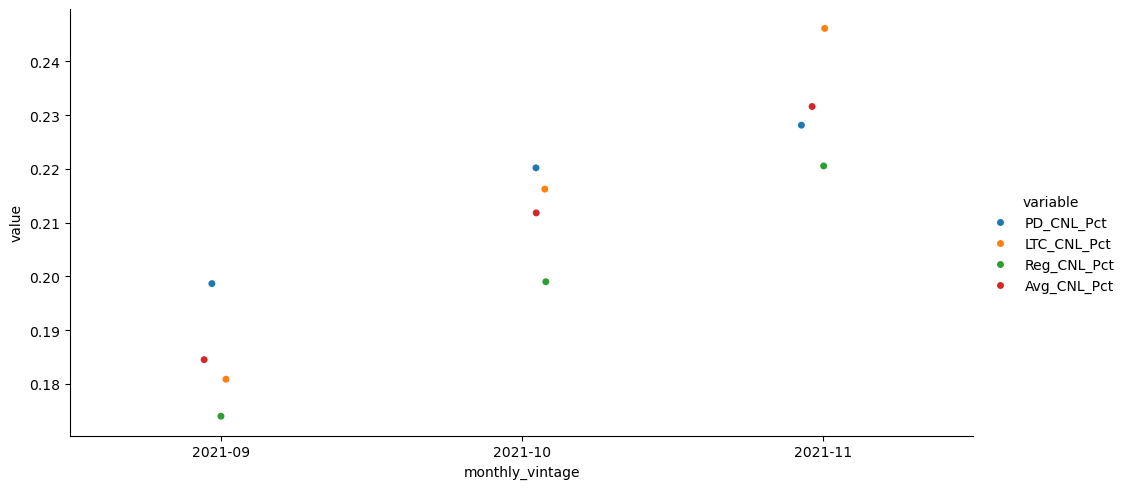

In [31]:
sns.catplot(
    data=pcts_df.melt(ignore_index=False).reset_index(), 
    x='monthly_vintage', y='value', hue='variable', aspect=2);

In [32]:
loss_means_ss = pcts_df['Avg_CNL_Pct']

loss_means_ss

monthly_vintage
2021-09    0.184516
2021-10    0.211809
2021-11    0.231587
Freq: M, Name: Avg_CNL_Pct, dtype: float64

In [33]:
index_ss2 = df_train2['monthly_vintage'].isin(values=value_counts_ss.index)
filtered_df2 = df_train2.loc[index_ss2, :]

print(*map(lambda x: x.shape, [df_train2, filtered_df2]), sep='\n')

(6405, 8)
(3617, 8)


In [34]:
yhat_means_ss = filtered_df2.groupby(by='monthly_vintage')['yhat'].mean()

yhat_means_ss

monthly_vintage
2021-09    0.373469
2021-10    0.370213
2021-11    0.366532
Freq: M, Name: yhat, dtype: float64

In [35]:
lgd_means_ss = loss_means_ss.div(other=yhat_means_ss)

lgd_means_ss

monthly_vintage
2021-09    0.494062
2021-10    0.572127
2021-11    0.631834
Freq: M, dtype: float64

In [36]:
filtered_df2['lgd_factor'] = filtered_df2['monthly_vintage'].map(arg=lgd_means_ss.to_dict())

filtered_df2.set_index(keys='monthly_vintage')['lgd_factor'].drop_duplicates()

monthly_vintage
2021-09    0.494062
2021-10    0.572127
2021-11    0.631834
Freq: M, Name: lgd_factor, dtype: float64

In [37]:
filtered_df2['ecnl2'] = filtered_df2['yhat'] * filtered_df2['lgd_factor']

filtered_df2

,bigaccountid__app,monthly_vintage,intopenbktype__app,amtfinanced__app,yhat,target,ecnl,ecnl_mod,lgd_factor,ecnl2
1094,5751827.0,2021-09,nan,25000.0,0.313227,0.000000,0.135439,0.135439,0.494062,0.154753
1095,5751913.0,2021-09,nan,22500.0,0.492307,0.915600,0.212873,0.212873,0.494062,0.243230
1096,5751944.0,2021-09,13.0,20500.0,0.243909,0.582735,0.105466,0.105466,0.494062,0.120506
1097,5752151.0,2021-09,nan,31500.0,0.294119,0.000000,0.127177,0.127177,0.494062,0.145313
1098,5752154.0,2021-09,nan,33500.0,0.592302,0.000000,0.256112,0.256112,0.494062,0.292634
...,...,...,...,...,...,...,...,...,...,...
4706,5844713.0,2021-11,nan,25000.0,0.367074,0.000000,0.158723,0.158723,0.631834,0.231930
4707,5844723.0,2021-11,nan,27500.0,0.551329,0.000000,0.238395,0.238395,0.631834,0.348348
4708,5844741.0,2021-11,nan,27500.0,0.303197,0.000000,0.131102,0.131102,0.631834,0.191570
4709,5844783.0,2021-11,nan,27500.0,0.127664,0.000000,0.055202,0.055202,0.631834,0.080663


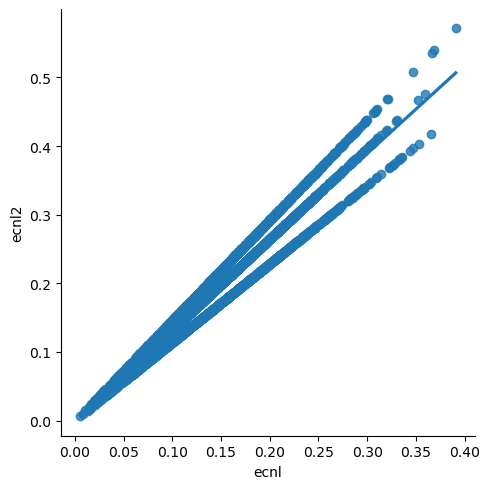

In [38]:
sns.lmplot(data=filtered_df2, x='ecnl', y='ecnl2');

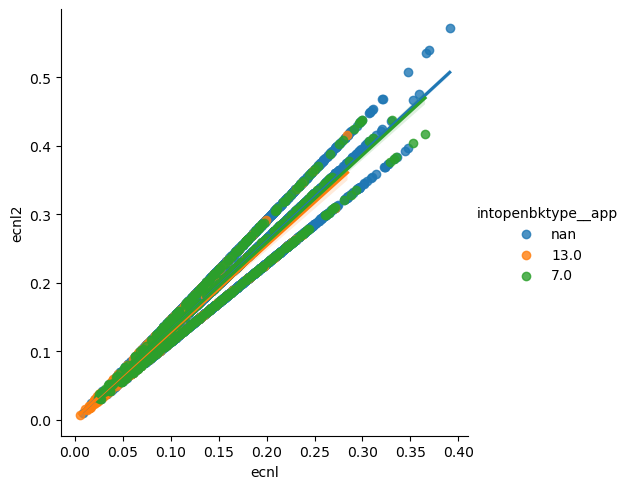

In [39]:
sns.lmplot(data=filtered_df2, x='ecnl', y='ecnl2', hue='intopenbktype__app');

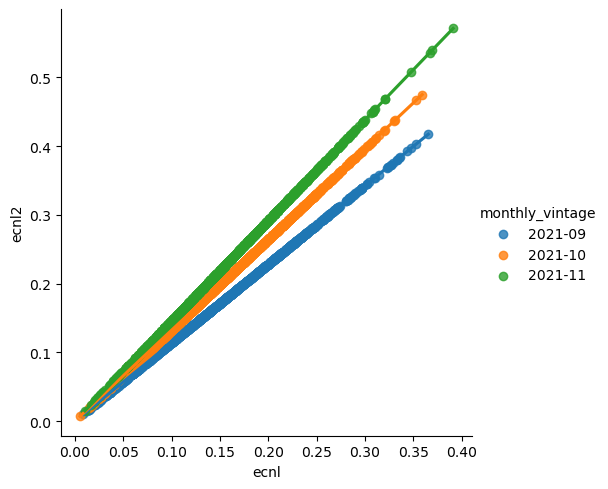

In [40]:
sns.lmplot(data=filtered_df2, x='ecnl', y='ecnl2', hue='monthly_vintage');

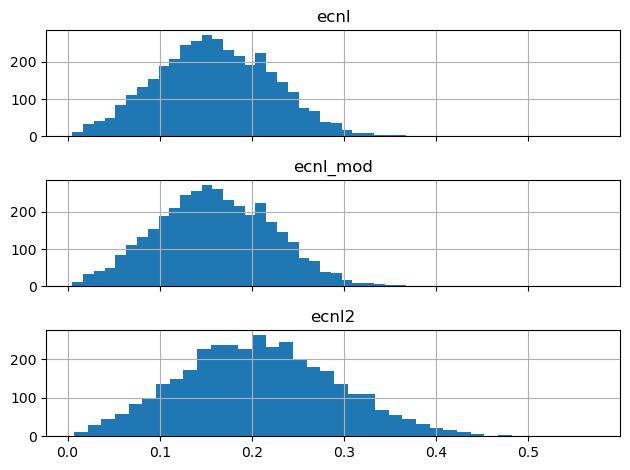

In [41]:
filtered_df2.filter(like='ecnl').hist(bins='auto', layout=(-1, 1), sharex=True)
plt.tight_layout();

<Axes: ylabel='Frequency'>

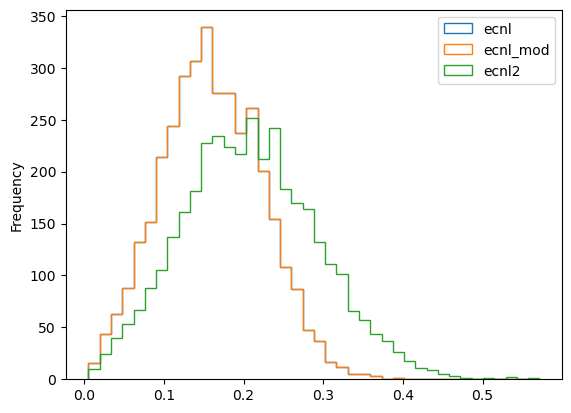

In [42]:
filtered_df2.filter(like='ecnl').plot(kind='hist', bins=int(4e1), histtype='step')

In [43]:
filtered_df2.filter(like='ecnl').describe().round(decimals=3)

,ecnl,ecnl_mod,ecnl2
count,3617.000,3617.000,3617.000
mean,0.160,0.160,0.208
std,0.063,0.063,0.084
min,0.005,0.005,0.007
25%,0.116,0.116,0.149
50%,0.158,0.158,0.206
75%,0.206,0.206,0.263
max,0.391,0.391,0.571


monthly_vintage
2021-09    Axes(0.125,0.11;0.775x0.77)
2021-10    Axes(0.125,0.11;0.775x0.77)
2021-11    Axes(0.125,0.11;0.775x0.77)
Freq: M, dtype: object

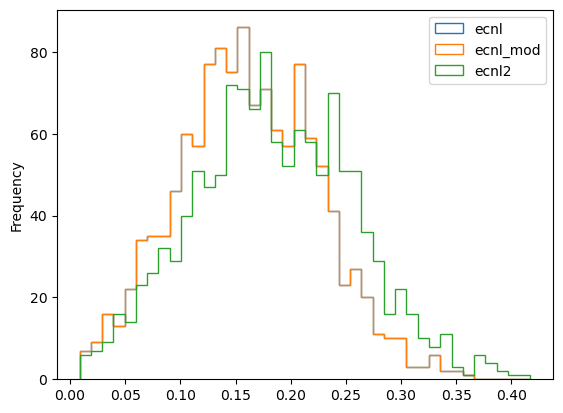

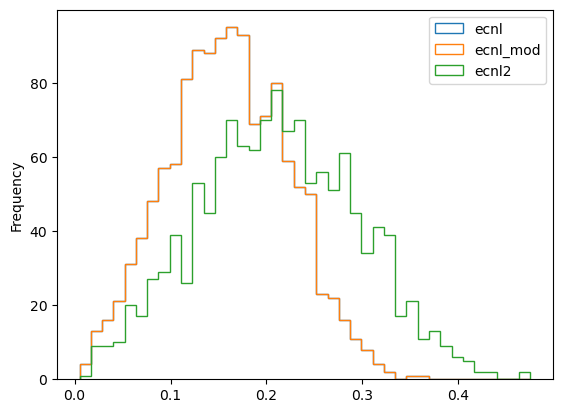

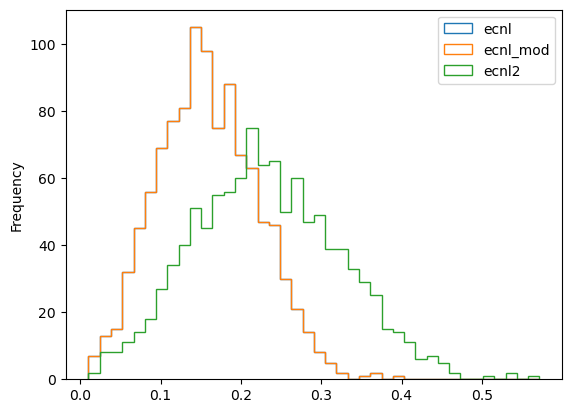

In [44]:
(
    filtered_df2
    .groupby(by='monthly_vintage')
    .apply(func=lambda x: x.filter(like='ecnl').plot(kind='hist', bins=int(4e1), histtype='step'))
)

In [45]:
(
    filtered_df2
    .groupby(by='monthly_vintage')
    .apply(func=lambda x: x.filter(like='ecnl').describe())
)

ecnl     ecnl_mod        ecnl2
monthly_vintage                                             
2021-09         count  1256.000000  1256.000000  1256.000000
                mean      0.161488     0.161488     0.184516
                std       0.063701     0.063701     0.072785
                min       0.008574     0.008574     0.009797
                25%       0.117301     0.117301     0.134029
                50%       0.158386     0.158386     0.180972
                75%       0.207632     0.207632     0.237241
                max       0.365285     0.365285     0.417376
2021-10         count  1293.000000  1293.000000  1293.000000
                mean      0.160080     0.160080     0.211809
                std       0.062743     0.062743     0.083018
                min       0.005228     0.005228     0.006918
                25%       0.115861     0.115861     0.153301
                50%       0.158907     0.158907     0.210256
                75%       0.205972     0.205972     0.272531
                max       0.359050     0.359050     0.475075
2021-11         count  1068.000000  1068.000000  1068.000000
                mean      0.158488     0.158488     0.231587
                std       0.062064     0.062064     0.090690
                min       0.010192     0.010192     0.014893
                25%       0.113818     0.113818     0.166314
                50%       0.155335     0.155335     0.226979
                75%       0.200811     0.200811     0.293430
                max       0.391010     0.391010     0.571353

In [46]:
loss_means_ss

monthly_vintage
2021-09    0.184516
2021-10    0.211809
2021-11    0.231587
Freq: M, Name: Avg_CNL_Pct, dtype: float64

In [47]:
!rm -rfv output cls_model_preprocessing.pkl preprocessing.py

removed directory: ‘output/noPTImodel7’
removed directory: ‘output’
removed ‘cls_model_preprocessing.pkl’
removed ‘preprocessing.py’


In [48]:
assert False, 'Nothing below this line was run'

AssertionError: Nothing below this line was run

In [ ]:
# get tier thresholds for training data
df_tmp = df_train.copy()
df_tmp.sort_values(by='ecnl_mod', ascending=True, inplace=True)
df_tmp['rank'] = list(range(1, df_tmp.shape[0]+1))
df_tmp['prop_rank'] = df_tmp['rank'] / df_tmp.shape[0]
df_tmp['tier'] = df_tmp['prop_rank'].apply(get_tier_from_rank)
df_tiers = df_tmp.groupby(by='tier', as_index=False).agg({
    'ecnl_mod': 'max',
})
# get tier
dict_tiers = dict(zip(df_tiers['tier'], df_tiers['ecnl_mod']))
print(dict_tiers)
df_train['tier'] = df_train['ecnl_mod'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# show
df_train

In [ ]:
# get tier freq
ser_freq = df_train['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['tier','prop']
df_freq

In [ ]:
# get approval rate
dict_tmp = dict(zip(df_freq['tier'], df_freq['prop']))
try:
    flt_approval_rate = 1 - dict_tmp['Decline']
except KeyError:
    flt_approval_rate = 1.0
# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of Modified ECNL in PD Training Data
Approval Rate = {flt_approval_rate:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('Modified ECNL')
sns.kdeplot(list(df_train['ecnl_mod']), ax=ax, label='Modified ECNL')
#ax.axvline(flt_decline_threshold, linestyle='--', color='red', label=f'Decline Threshold: {flt_decline_threshold:0.4f}')
# lelgend
plt.legend()
# show
plt.show()

### Get production data

In [ ]:
%%time

# import data from retro scoring that has been joined to TSP to get gen 12 features
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/08_retro_scoring/06_create_df/{str_filename}'
df_prod = pd.read_parquet(str_uri)

# get year-month from dtmFunded - use this not application date for subsetting
df_prod['year_month'] = df_prod['dtmFunded'].apply(get_year_month)

# convert to datetime
df_prod['applicationdate__app'] = pd.to_datetime(df_prod['applicationdate__app'])
# drop because they break preprocessing
list_cols = [
    'applicationdayofweek__app',
]
df_prod.drop(list_cols, axis=1, inplace=True)
# get features 100% NaN and drop
ser_isnull = df_prod.isnull().mean()
list_all_nan = list(ser_isnull[ser_isnull==1.0].index)
df_prod.drop(list_all_nan, axis=1, inplace=True)
# subset
df_prod = df_prod[df_prod['year_month'].isin(list_str_year_month)].copy()
# preprocess
df_prod = cls_model_preprocessing.transform(df_prod)
# predict
df_prod['yhat'] = cls_model_inference.predict_proba(df_prod[list_cols_model])[:, 1]
# show
df_prod

In [ ]:
# freq 
ser_freq = df_prod['year_month'].value_counts()
df_freq = ser_freq.reset_index()
df_freq.columns = ['year_month', 'count']
df_freq

In [ ]:
# group to simulate the API
df_prod = df_prod.groupby(by='bigAccountId', as_index=False).agg({
    'amtfinanced__app': 'first',
    'intopenbktype__app': 'first',
    'yhat': 'mean',
})
# join
df_prod = pd.merge(
    left=df_prod,
    right=df_target,
    on='bigAccountId',
    how='inner',
)
# multiply by lgd constant
df_prod['ecnl'] = df_prod['yhat'] * flt_lgd_constant
# get modified ecnl
#df_prod['ecnl_mod'] = flt_intercept_mike + (df_prod['ecnl'] * flt_coef_mike)
df_prod['ecnl_mod'] = df_prod['ecnl'] + flt_factor_add_all
df_prod

In [ ]:
# get n unique
int_n_unique = len(list(df_prod['target'].unique()))
# if it is not a 0 or 1 (i.e., 60dpd24)
if int_n_unique > 2:
    # get proportion of amount financed
    df_prod['target'] = df_prod['target'] / df_prod['amtfinanced__app']
else:
    pass

In [ ]:
# get tier thresholds for training data
df_tmp = df_prod.copy()
df_tmp.sort_values(by='ecnl_mod', ascending=True, inplace=True)
df_tmp['rank'] = list(range(1, df_tmp.shape[0]+1))
df_tmp['prop_rank'] = df_tmp['rank'] / df_tmp.shape[0]
df_tmp['tier'] = df_tmp['prop_rank'].apply(get_tier_from_rank)
df_tiers = df_tmp.groupby(by='tier', as_index=False).agg({
    'ecnl_mod': 'max',
})
# get tier
dict_tiers = dict(zip(df_tiers['tier'], df_tiers['ecnl_mod']))
print(dict_tiers)
df_prod['tier'] = df_prod['ecnl_mod'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# show
df_prod

In [ ]:
# get tier freq
ser_freq = df_prod['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['tier','prop']
df_freq

In [ ]:
# get approval rate
dict_tmp = dict(zip(df_freq['tier'], df_freq['prop']))
try:
    flt_approval_rate = 1 - dict_tmp['Decline']
except KeyError:
    flt_approval_rate = 1.0
# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of Modified ECNL in Production Data
Approval Rate = {flt_approval_rate:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('Modified ECNL')
sns.kdeplot(list(df_prod['ecnl_mod']), ax=ax, label='Modified ECNL')
#ax.axvline(flt_decline_threshold, linestyle='--', color='red', label=f'Decline Threshold: {flt_decline_threshold:0.4f}')
# lelgend
plt.legend()
# show
plt.show()

### Show both distributions on the same plot

In [ ]:
plot_modified_ecnl_distributions(
    df_train_tmp=df_train, 
    df_prod_tmp=df_prod, 
    flt_decline_threshold=flt_decline_threshold,
)

### Plot actuals on same plot

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
str_title = 'Distributions of Actual Proportion Loss For Train and Production'
ax.set_title(str_title)
ax.set_xlabel('Actual Proportion Loss')
sns.kdeplot(df_train['target'], ax=ax, label='Train')
sns.kdeplot(df_prod['target'], ax=ax, label='Production')
plt.legend()
plt.show()

### Get mean and SD from production for simulating tier threshold in another notebook

In [ ]:
flt_mean_tmp = df_prod['ecnl_mod'].mean()
flt_sd_tmp = df_prod['ecnl_mod'].std()
print(f'Production Mean: {flt_mean_tmp:0.4f}')
print(f'Production SD: {flt_sd_tmp:0.4f}')

### Get factors

#### All

In [ ]:
# subset
df_train_tmp = df_train.copy()
df_prod_tmp = df_prod.copy()

In [ ]:
# modified ecnl distributions
plot_modified_ecnl_distributions(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp, 
    flt_decline_threshold=flt_decline_threshold,
)

In [ ]:
# tier freq
df_tier_freq = get_tier_freq(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
df_tier_freq

In [ ]:
# get ratios
dict_output = get_ecnl_to_target_ratios(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
dict_output

In [ ]:
# test factors
df_out = test_factors(
    int_n_factors=int_n_factors, 
    df_prod_tmp=df_prod_tmp, 
    flt_sum_target_prod=dict_output['flt_sum_target_prod'],
    flt_ratio_train=dict_output['flt_ratio_train'],
)
df_out

In [ ]:
# make plot
flt_factor_best = make_plot(
    df_out=df_out,
    flt_ratio_train=dict_output['flt_ratio_train'],
)

In [ ]:
# apply factor
df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor_best
# get tier
df_prod_tmp['tier_tmp'] = df_prod_tmp['ecnl_mod_tmp'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# get tier freq
ser_freq = df_prod_tmp['tier_tmp'].value_counts(normalize=True)
df_tier_freq_tmp = ser_freq.reset_index()
df_tier_freq_tmp.columns = ['tier','prop_factor']
# join
df_tier_freq_tmp = pd.merge(
    left=df_tier_freq,
    right=df_tier_freq_tmp,
    on='tier',
    how='outer',
)
df_tier_freq_tmp.fillna(0, inplace=True)
df_tier_freq_tmp

In [ ]:
# show
plot_distributions_before_and_after_factor(
    df_prod_tmp=df_prod_tmp, 
    flt_factor_best=flt_factor_best,
)

#### BK7

In [ ]:
# subset
df_train_tmp = df_train[df_train['intopenbktype__app'] == '7.0'].copy()
df_prod_tmp = df_prod[df_prod['intopenbktype__app'] == '7.0'].copy()

In [ ]:
# modified ecnl distributions
plot_modified_ecnl_distributions(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp, 
    flt_decline_threshold=flt_decline_threshold,
)

In [ ]:
# tier freq
df_tier_freq = get_tier_freq(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
df_tier_freq

In [ ]:
# get ratios
dict_output = get_ecnl_to_target_ratios(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
dict_output

In [ ]:
# test factors
df_out = test_factors(
    int_n_factors=int_n_factors, 
    df_prod_tmp=df_prod_tmp, 
    flt_sum_target_prod=dict_output['flt_sum_target_prod'],
    flt_ratio_train=dict_output['flt_ratio_train'],
)
df_out

In [ ]:
# make plot
flt_factor_best = make_plot(
    df_out=df_out,
    flt_ratio_train=dict_output['flt_ratio_train'],
)

In [ ]:
# apply factor
df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor_best
# get tier
df_prod_tmp['tier_tmp'] = df_prod_tmp['ecnl_mod_tmp'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# get tier freq
ser_freq = df_prod_tmp['tier_tmp'].value_counts(normalize=True)
df_tier_freq_tmp = ser_freq.reset_index()
df_tier_freq_tmp.columns = ['tier','prop_factor']
# join
df_tier_freq_tmp = pd.merge(
    left=df_tier_freq,
    right=df_tier_freq_tmp,
    on='tier',
    how='outer',
)
df_tier_freq_tmp.fillna(0, inplace=True)
df_tier_freq_tmp

In [ ]:
# show
plot_distributions_before_and_after_factor(
    df_prod_tmp=df_prod_tmp, 
    flt_factor_best=flt_factor_best,
)

#### BK13

In [ ]:
# subset
df_train_tmp = df_train[df_train['intopenbktype__app'] == '13.0'].copy()
df_prod_tmp = df_prod[df_prod['intopenbktype__app'] == '13.0'].copy()

In [ ]:
# modified ecnl distributions
plot_modified_ecnl_distributions(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp, 
    flt_decline_threshold=flt_decline_threshold,
)

In [ ]:
# tier freq
df_tier_freq = get_tier_freq(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
df_tier_freq

In [ ]:
# get ratios
dict_output = get_ecnl_to_target_ratios(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
dict_output

In [ ]:
# test factors
df_out = test_factors(
    int_n_factors=int_n_factors, 
    df_prod_tmp=df_prod_tmp, 
    flt_sum_target_prod=dict_output['flt_sum_target_prod'],
    flt_ratio_train=dict_output['flt_ratio_train'],
)
df_out

In [ ]:
# make plot
flt_factor_best = make_plot(
    df_out=df_out,
    flt_ratio_train=dict_output['flt_ratio_train'],
)

In [ ]:
# apply factor
df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor_best
# get tier
df_prod_tmp['tier_tmp'] = df_prod_tmp['ecnl_mod_tmp'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# get tier freq
ser_freq = df_prod_tmp['tier_tmp'].value_counts(normalize=True)
df_tier_freq_tmp = ser_freq.reset_index()
df_tier_freq_tmp.columns = ['tier','prop_factor']
# join
df_tier_freq_tmp = pd.merge(
    left=df_tier_freq,
    right=df_tier_freq_tmp,
    on='tier',
    how='outer',
)
df_tier_freq_tmp.fillna(0, inplace=True)
df_tier_freq_tmp

In [ ]:
# show
plot_distributions_before_and_after_factor(
    df_prod_tmp=df_prod_tmp, 
    flt_factor_best=flt_factor_best,
)

#### A1 NoBK

In [ ]:
# subset
df_train_tmp = df_train[(df_train['tier'] == 'A1') & (df_train['intopenbktype__app'] == 'nan')].copy()
df_prod_tmp = df_prod[(df_prod['tier'] == 'A1') & (df_prod['intopenbktype__app'] == 'nan')].copy()

In [ ]:
# modified ecnl distributions
plot_modified_ecnl_distributions(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp, 
    flt_decline_threshold=flt_decline_threshold,
)

In [ ]:
# tier freq
df_tier_freq = get_tier_freq(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
df_tier_freq

In [ ]:
# get ratios
dict_output = get_ecnl_to_target_ratios(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
dict_output

In [ ]:
# test factors
df_out = test_factors(
    int_n_factors=int_n_factors, 
    df_prod_tmp=df_prod_tmp, 
    flt_sum_target_prod=dict_output['flt_sum_target_prod'],
    flt_ratio_train=dict_output['flt_ratio_train'],
)
df_out

In [ ]:
# make plot
flt_factor_best = make_plot(
    df_out=df_out,
    flt_ratio_train=dict_output['flt_ratio_train'],
)

In [ ]:
# apply factor
df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor_best
# get tier
df_prod_tmp['tier_tmp'] = df_prod_tmp['ecnl_mod_tmp'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# get tier freq
ser_freq = df_prod_tmp['tier_tmp'].value_counts(normalize=True)
df_tier_freq_tmp = ser_freq.reset_index()
df_tier_freq_tmp.columns = ['tier','prop_factor']
# join
df_tier_freq_tmp = pd.merge(
    left=df_tier_freq,
    right=df_tier_freq_tmp,
    on='tier',
    how='outer',
)
df_tier_freq_tmp.fillna(0, inplace=True)
df_tier_freq_tmp

In [ ]:
# show
plot_distributions_before_and_after_factor(
    df_prod_tmp=df_prod_tmp, 
    flt_factor_best=flt_factor_best,
)

#### A NoBK

In [ ]:
# subset
df_train_tmp = df_train[(df_train['tier'] == 'A') & (df_train['intopenbktype__app'] == 'nan')].copy()
df_prod_tmp = df_prod[(df_prod['tier'] == 'A') & (df_prod['intopenbktype__app'] == 'nan')].copy()

In [ ]:
# modified ecnl distributions
plot_modified_ecnl_distributions(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp, 
    flt_decline_threshold=flt_decline_threshold,
)

In [ ]:
# tier freq
df_tier_freq = get_tier_freq(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
df_tier_freq

In [ ]:
# get ratios
dict_output = get_ecnl_to_target_ratios(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
dict_output

In [ ]:
# test factors
df_out = test_factors(
    int_n_factors=int_n_factors, 
    df_prod_tmp=df_prod_tmp, 
    flt_sum_target_prod=dict_output['flt_sum_target_prod'],
    flt_ratio_train=dict_output['flt_ratio_train'],
)
df_out

In [ ]:
# make plot
flt_factor_best = make_plot(
    df_out=df_out,
    flt_ratio_train=dict_output['flt_ratio_train'],
)

In [ ]:
# apply factor
df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor_best
# get tier
df_prod_tmp['tier_tmp'] = df_prod_tmp['ecnl_mod_tmp'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# get tier freq
ser_freq = df_prod_tmp['tier_tmp'].value_counts(normalize=True)
df_tier_freq_tmp = ser_freq.reset_index()
df_tier_freq_tmp.columns = ['tier','prop_factor']
# join
df_tier_freq_tmp = pd.merge(
    left=df_tier_freq,
    right=df_tier_freq_tmp,
    on='tier',
    how='outer',
)
df_tier_freq_tmp.fillna(0, inplace=True)
df_tier_freq_tmp

In [ ]:
# show
plot_distributions_before_and_after_factor(
    df_prod_tmp=df_prod_tmp, 
    flt_factor_best=flt_factor_best,
)

#### B

In [ ]:
# subset
df_train_tmp = df_train[df_train['tier'] == 'B'].copy()
df_prod_tmp = df_prod[df_prod['tier'] == 'B'].copy()

In [ ]:
# modified ecnl distributions
plot_modified_ecnl_distributions(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp, 
    flt_decline_threshold=flt_decline_threshold,
)

In [ ]:
# tier freq
df_tier_freq = get_tier_freq(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
df_tier_freq

In [ ]:
# get ratios
dict_output = get_ecnl_to_target_ratios(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
dict_output

In [ ]:
# test factors
df_out = test_factors(
    int_n_factors=int_n_factors, 
    df_prod_tmp=df_prod_tmp, 
    flt_sum_target_prod=dict_output['flt_sum_target_prod'],
    flt_ratio_train=dict_output['flt_ratio_train'],
)
df_out

In [ ]:
# make plot
flt_factor_best = make_plot(
    df_out=df_out,
    flt_ratio_train=dict_output['flt_ratio_train'],
)

In [ ]:
# apply factor
df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor_best
# get tier
df_prod_tmp['tier_tmp'] = df_prod_tmp['ecnl_mod_tmp'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# get tier freq
ser_freq = df_prod_tmp['tier_tmp'].value_counts(normalize=True)
df_tier_freq_tmp = ser_freq.reset_index()
df_tier_freq_tmp.columns = ['tier','prop_factor']
# join
df_tier_freq_tmp = pd.merge(
    left=df_tier_freq,
    right=df_tier_freq_tmp,
    on='tier',
    how='outer',
)
df_tier_freq_tmp.fillna(0, inplace=True)
df_tier_freq_tmp

In [ ]:
# show
plot_distributions_before_and_after_factor(
    df_prod_tmp=df_prod_tmp, 
    flt_factor_best=flt_factor_best,
)

#### C

In [ ]:
# subset
df_train_tmp = df_train[df_train['tier'] == 'C'].copy()
df_prod_tmp = df_prod[df_prod['tier'] == 'C'].copy()

In [ ]:
# modified ecnl distributions
plot_modified_ecnl_distributions(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp, 
    flt_decline_threshold=flt_decline_threshold,
)

In [ ]:
# tier freq
df_tier_freq = get_tier_freq(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
df_tier_freq

In [ ]:
# get ratios
dict_output = get_ecnl_to_target_ratios(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
dict_output

In [ ]:
# test factors
df_out = test_factors(
    int_n_factors=int_n_factors, 
    df_prod_tmp=df_prod_tmp, 
    flt_sum_target_prod=dict_output['flt_sum_target_prod'],
    flt_ratio_train=dict_output['flt_ratio_train'],
)
df_out

In [ ]:
# make plot
flt_factor_best = make_plot(
    df_out=df_out,
    flt_ratio_train=dict_output['flt_ratio_train'],
)

In [ ]:
# apply factor
df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor_best
# get tier
df_prod_tmp['tier_tmp'] = df_prod_tmp['ecnl_mod_tmp'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# get tier freq
ser_freq = df_prod_tmp['tier_tmp'].value_counts(normalize=True)
df_tier_freq_tmp = ser_freq.reset_index()
df_tier_freq_tmp.columns = ['tier','prop_factor']
# join
df_tier_freq_tmp = pd.merge(
    left=df_tier_freq,
    right=df_tier_freq_tmp,
    on='tier',
    how='outer',
)
df_tier_freq_tmp.fillna(0, inplace=True)
df_tier_freq_tmp

In [ ]:
# show
plot_distributions_before_and_after_factor(
    df_prod_tmp=df_prod_tmp, 
    flt_factor_best=flt_factor_best,
)

#### D

In [ ]:
# subset
df_train_tmp = df_train[df_train['tier'] == 'D'].copy()
df_prod_tmp = df_prod[df_prod['tier'] == 'D'].copy()

In [ ]:
# modified ecnl distributions
plot_modified_ecnl_distributions(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp, 
    flt_decline_threshold=flt_decline_threshold,
)

In [ ]:
# tier freq
df_tier_freq = get_tier_freq(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
df_tier_freq

In [ ]:
# get ratios
dict_output = get_ecnl_to_target_ratios(
    df_train_tmp=df_train_tmp, 
    df_prod_tmp=df_prod_tmp,
)
dict_output

In [ ]:
# test factors
df_out = test_factors(
    int_n_factors=int_n_factors, 
    df_prod_tmp=df_prod_tmp, 
    flt_sum_target_prod=dict_output['flt_sum_target_prod'],
    flt_ratio_train=dict_output['flt_ratio_train'],
)
df_out

In [ ]:
# make plot
flt_factor_best = make_plot(
    df_out=df_out,
    flt_ratio_train=dict_output['flt_ratio_train'],
)

In [ ]:
# apply factor
df_prod_tmp['ecnl_mod_tmp'] = df_prod_tmp['ecnl_mod'] + flt_factor_best
# get tier
df_prod_tmp['tier_tmp'] = df_prod_tmp['ecnl_mod_tmp'].apply(
    lambda x: get_tier(
        fltDebtorScore=x,
        dict_tiers=dict_tiers,
    ),
)
# get tier freq
ser_freq = df_prod_tmp['tier_tmp'].value_counts(normalize=True)
df_tier_freq_tmp = ser_freq.reset_index()
df_tier_freq_tmp.columns = ['tier','prop_factor']
# join
df_tier_freq_tmp = pd.merge(
    left=df_tier_freq,
    right=df_tier_freq_tmp,
    on='tier',
    how='outer',
)
df_tier_freq_tmp.fillna(0, inplace=True)
df_tier_freq_tmp

In [ ]:
# show
plot_distributions_before_and_after_factor(
    df_prod_tmp=df_prod_tmp, 
    flt_factor_best=flt_factor_best,
)

### Clean-up

In [ ]:
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in list_str_filename:
    os.remove(str_filename)